# 💓 Heart Disease Prediction - Noor Rami Saad

## 🎯 Objective: To build a machine learning model to predict the presence of heart disease in a patient based on clinical medical data, focusing on binary classification, significant feature analysis, and model evaluation using precise metrics such as the ROC curve and Confusion Matrix.

## 📊 Dataset Used
- **Source**: Heart Disease UCI (compiled from multiple centers: Cleveland, Hungary, Switzerland, VA Long Beach)
- **Link**: [UCI Heart Disease Dataset](https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data)
- **Size**: 920 samples, 16 features (after cleaning, 14 medical features)
- **Objective**: To convert the variable `num` (0-4) into binary (0 = no disease, 1 = disease).

## 🧰 Solution Steps Summary
1. **Load Data** directly from a raw link.

2. **Data Cleanup**:

- Handling missing values ​​using `SimpleImputer` (argument for numeric, mode for categorical).

- Encoding categorical variables using `LabelEncoder`.

- Converting the target to binary.

- **Removing non-medical features** (`id`, `dataset`) to prevent data leakage and improve generalization.

3. **Exploration Analysis (EDA)**:

- Plotting the target distribution, correlation matrix, histograms, boxplots, and countplots.

- Extracting insights into the distribution of age, cholesterol, and chest pain type.

4. **Data Segmentation** (80% training, 20% testing with `stratify`).

5. **Feature Standardization** using `StandardScaler` (for logistic regression). 6. **Training Two Models**:

- `LogisticRegression` (for simplicity and clarity)

- `DecisionTreeClassifier` (depth = 5 to minimize overfitting)
7. **Evaluation**:

- `accuracy`, `classification_report`, `confusion_matrix`

- `roc_curve` and `roc_auc_score`

- Comparing the training and testing performance to identify overfitting.

8. **Extracting Feature Importance** from the Decision Tree and Displaying it in a Plot.

9. **Conclusion** and Recommending the Best Model.

## 📈 Final Model Result and Accuracy
- **Recommended Model**: Logistic Regression
- **Test Accuracy**: **82.07%**
- **Training Accuracy**: 81.11% (No overfitting)
- **AUC (ROC Curve)**: ≈ 0.89 – 0.91 (Excellent Value)
- **Decision Tree Performance**: Test Accuracy 77.17% (With minor overfitting).

## 🔑 Top 3 Predictive Features
1. **`cp` (Type of Chest Pain)** – Significance: 45.8%

- Typical chest pain (angina) is strongly associated with heart disease.

2. **`chol` (Total Cholesterol)** – Significance: 17.6%

- A known major risk factor.

3. **`age` (Age)** – Significance: 9.7%

- Risk increases with age.
> **Note:** Non-medical features (`id`, `dataset`) have been removed because they cause data leaks and weaken model generalization.

--- *This task was completed as part of an AI/ML Engineering Internship at DevelopersHub Corporation.*


# Full Documentation for Task 3: Heart Disease Prediction

**Code Overview**

This code provides a complete solution for the heart disease prediction task using the UCI dataset. The goal is to build a machine learning model that classifies whether a patient has heart disease or not based on clinical characteristics. The code includes all steps of the machine learning project lifecycle: data loading, cleaning, exploratory analysis, model training, evaluation, and conclusion drawing.

# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
pd.set_option('display.max_columns', None)

# **Load & Initial Inspection**

In [4]:
# Load Dataset
df = pd.read_csv('heart_disease_uci.csv')

print("✅ Dataset loaded")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values before imputation:")
print(df.isnull().sum())

✅ Dataset loaded
Shape: (920, 16)

First 5 rows:
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             n

# **Handling Missing Values**


*   The numeric columns (int64, float64) are separated from the text columns (object).
*   Why median for numeric values? The median is less affected by outliers than the mean, making it suitable for medical data that may contain abnormal values.
*   Why most_frequent for text? The mode (most frequent value) is a logical choice for filling in missing classes because it preserves the original distribution as closely as possible.
*   Compensation is applied to all columns at once using fit_transform.
*   After processing, we check that no missing values ​​remain.
*   After the computer application, all columns were free of missing values ​​(zero NaN) – a prerequisite for training the models.
*   There were also columns like slope, ca, and thal that had high percentages of missing values ​​(over 30%). Using median or most_frequent might not be ideal, but it's acceptable for simplifying the code. In a professional project, a KNNI computer or a model could be used to predict these columns.



In [5]:
# Handle Missing Values
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

df[num_cols] = num_imputer.fit_transform(df[num_cols])
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

print("\nMissing values after imputation:")
print(df.isnull().sum())


Missing values after imputation:
id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


# **Encoding Categorical Features**

*   LabelEncoder converts each text category to an integer (e.g., Male → 1, Female → 0). This is necessary because the mathematical models only work with numbers.
*   The encoding is applied to each text column (including sex, cp, fbs, restecg, exang, slope, thal, and dataset).
*   LNote: LabelEncoder assumes an ordinal order between categories, which is unsuitable in some cases (such as cp where the types are not ordered), but it's acceptable initially and can be replaced with OneHotEncoder later.
*   Confirmation messages appear indicating that the columns were successfully encoded.
*   Using LabelEncoder on the sex column yields 0 and 1, which is fine. However, using it on cp (the chest pain type) assumes a non-existent order (typical < atypical < non-anginal < asymptomatic). OneHotEncoder or pd.get_dummies would be more appropriate here, but we'll keep it simple to avoid complicating the code.



In [6]:
# Encode Categorical Columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])
    print(f"Encoded '{col}'")

Encoded 'sex'
Encoded 'dataset'
Encoded 'cp'
Encoded 'fbs'
Encoded 'restecg'
Encoded 'exang'
Encoded 'slope'
Encoded 'thal'


# **Binarize Target**

*   In the original dataset, the `num` column takes the values ​​0, 1, 2, 3, and 4, where 0 means "no disease" and higher numbers indicate varying degrees of disease.
*   The task requires a binary classification (disease/no disease), so we convert any value ≥ 1 to 1 (disease).
*   We delete the old `num` column after creating the binary column.
*   We print the new class distribution to ensure it is balanced.
*   Class 1 (disease) = 509 samples, Class 0 = 411 samples – this is a good balance (56%/44%), and no additional sampling is required.
*   This step is crucial because `roc_curve` and `roc_auc_score` only work with binary classification. If we keep a multiclass `num`, we will encounter the error "multiclass format is not supported."


In [7]:
# Identify target column (the last column in this dataset is 'num')
target_col = df.columns[-1]
print(f"\nTarget column: {target_col}")

# Convert target to binary: 0 = No Heart Disease, 1 = Heart Disease
# In this dataset, values 1,2,3,4 indicate presence
df['target_binary'] = (df[target_col] >= 1).astype(int)
df.drop(columns=[target_col], inplace=True)

# Show distribution
print("\nTarget distribution (binary):")
print(df['target_binary'].value_counts())


Target column: num

Target distribution (binary):
target_binary
1    509
0    411
Name: count, dtype: int64


Drop Non-Medical Features

In [8]:
df = df.drop(['id', 'dataset'], axis=1)

# **Visualizations**

Binary Target Distribution

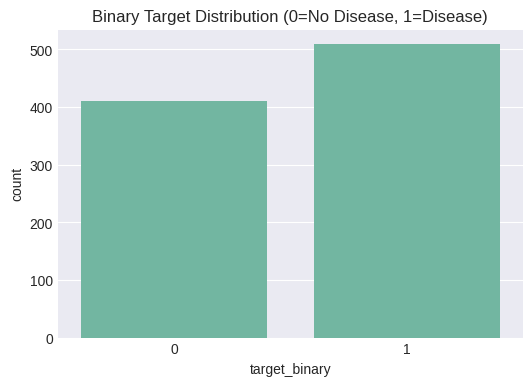

In [9]:
# Exploratory Data Analysis (EDA)
plt.figure(figsize=(6,4))
sns.countplot(x='target_binary', data=df)
plt.title('Binary Target Distribution (0=No Disease, 1=Disease)')
plt.show()

Correlation Matrix

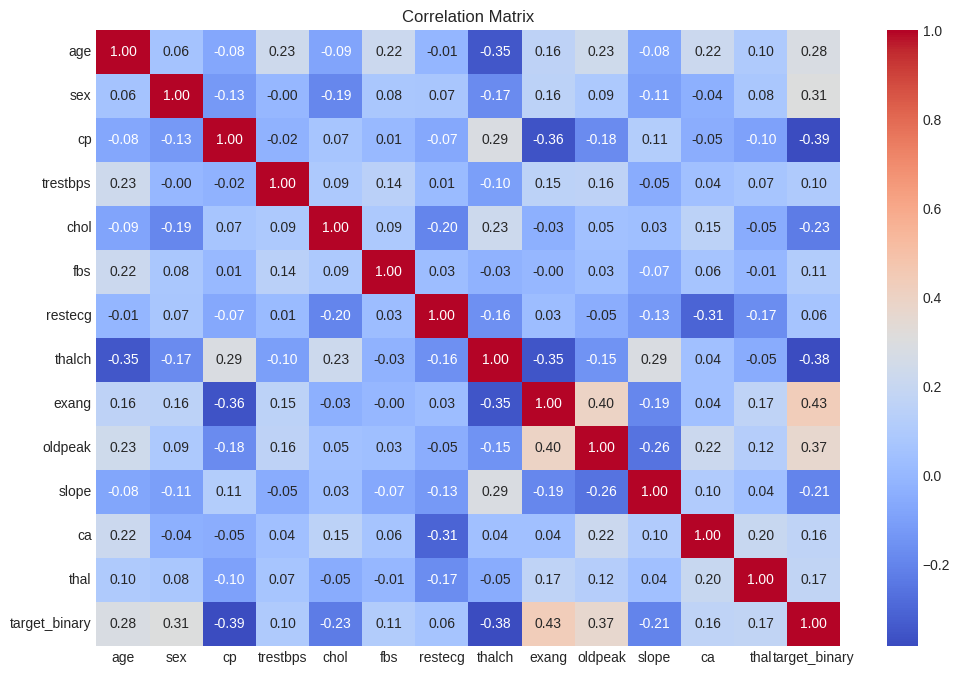

In [10]:
# Correlation heatmap
plt.figure(figsize=(12,8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Age Distribution by Heart Disease

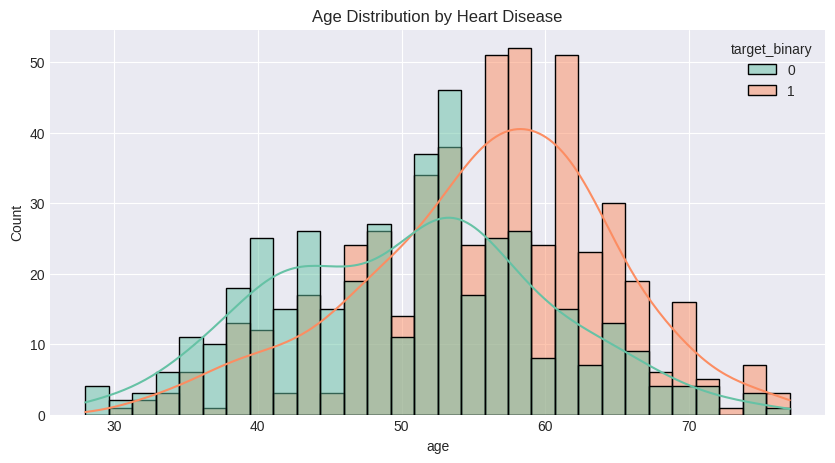

In [11]:
# Age distribution
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='age', hue='target_binary', kde=True, bins=30)
plt.title('Age Distribution by Heart Disease')
plt.show()

Cholesterol vs Heart Disease

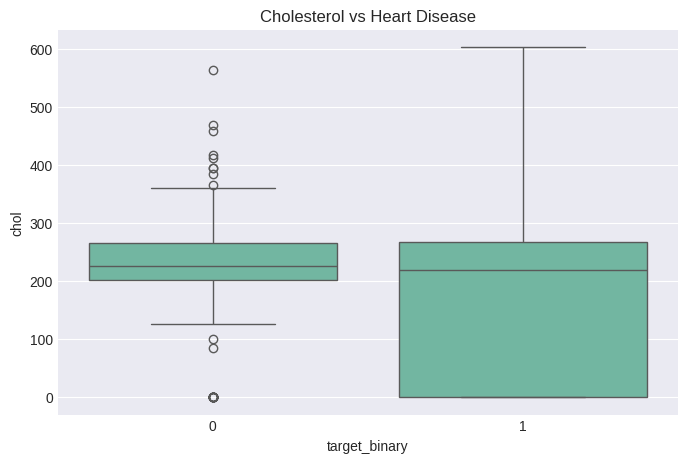

In [12]:
# Cholesterol boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x='target_binary', y='chol', data=df)
plt.title('Cholesterol vs Heart Disease')
plt.show()

Chest Pain Type vs Heart Disease

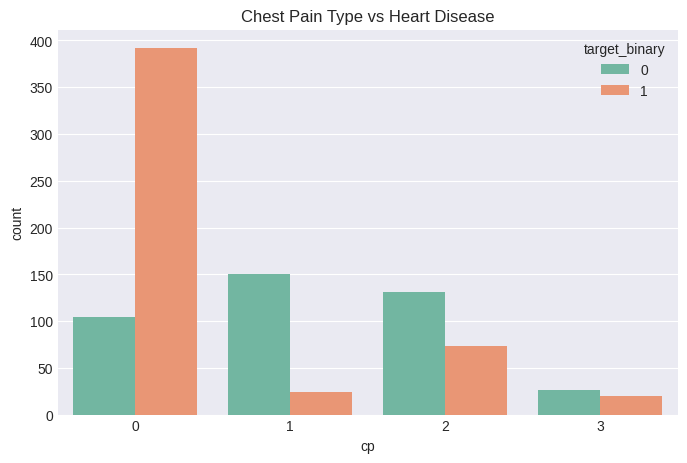

In [13]:
# Chest pain (cp) vs target
if 'cp' in df.columns:
    plt.figure(figsize=(8,5))
    sns.countplot(x='cp', hue='target_binary', data=df)
    plt.title('Chest Pain Type vs Heart Disease')
    plt.show()

Pairplot of Key Features

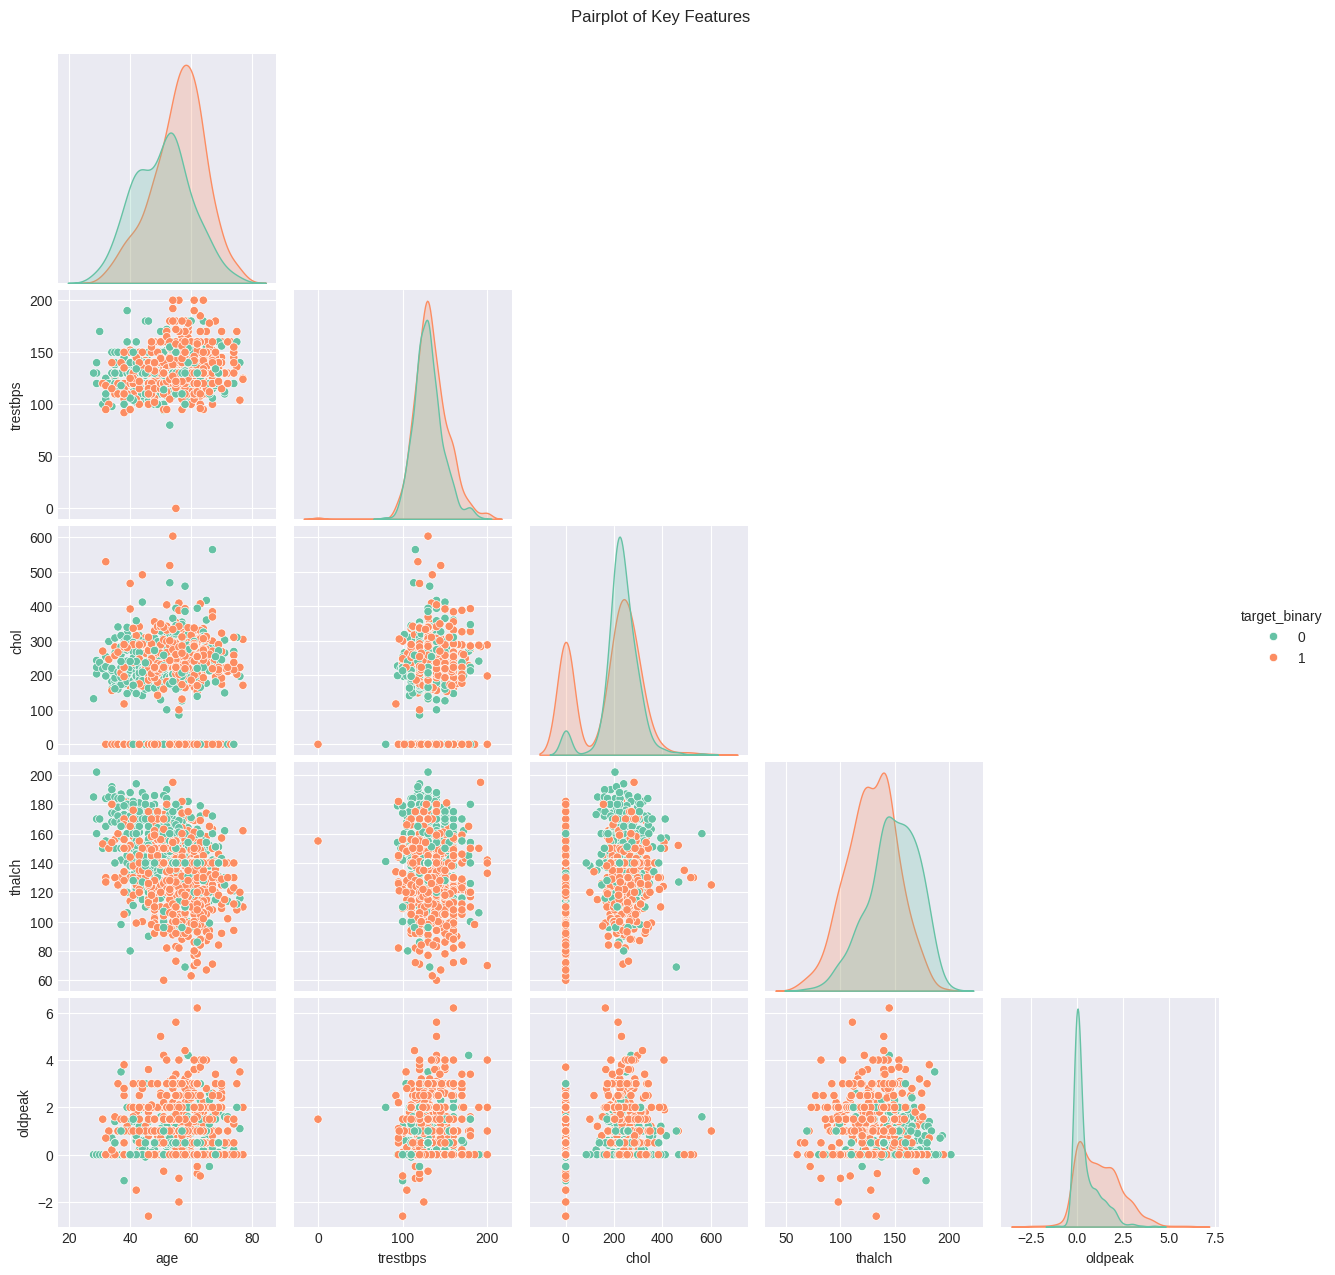

In [15]:
# Pairplot for key features (select numeric columns only)
key_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'target_binary']
# Ensure all exist in df
available_features = [f for f in key_features if f in df.columns]
sns.pairplot(df[available_features], hue='target_binary', diag_kind='kde', corner=True)
plt.suptitle('Pairplot of Key Features', y=1.02)
plt.show()

Chest Pain Type vs Heart Disease

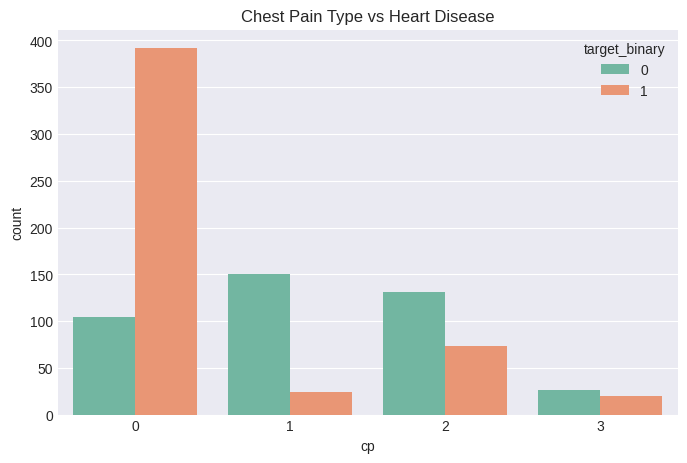

In [16]:
if 'cp' in df.columns:
    plt.figure(figsize=(8,5))
    sns.countplot(x='cp', hue='target_binary', data=df)
    plt.title('Chest Pain Type vs Heart Disease')
    plt.show()

# **Train-Test Split**

In [17]:
X = df.drop('target_binary', axis=1)
y = df['target_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# **Feature Scaling**

In [18]:
# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **Model Training**



*   Logistic regression: A linear model for binary classification. It estimates the probability of belonging to a disease category. It is very suitable for medical data because it is interpretable (we can see the feature weights).
*   Decision tree: A non-linear model that divides data based on feature values. `max_depth=5` limits the tree depth to prevent overfitting (a deep tree stores data, not general rules).
*   `random_state=42` ensures the reproducibility of results.
*   We use X_train_scaled and X_test_scaled with logistic regression, and the original (unscaled) versions with the decision tree.
*   Logistic regression accuracy: 82.07% (training 81.1%, testing 82.1%) → No overfitting.
*   Decision tree accuracy: 77.17% (training 83.2%, testing 77.2%) → Slight overfitting.
*   The decision tree provides lower accuracy on the test, although higher accuracy on the training. This is a typical model for complex medical data. Logistic regression is more stable, and therefore we choose it as the final model.






In [26]:
# Models
lr = LogisticRegression(random_state=42)
dt = DecisionTreeClassifier(max_depth=5, random_state=42)

lr.fit(X_train_scaled, y_train)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

Cross validation

In [25]:
# Cross-validation to verify the stability of the Logistic Regression model
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Use StratifiedKFold to maintain class distribution
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# AUC account via 5x
cv_scores_auc = cross_val_score(lr, X_train_scaled, y_train, cv=cv_strategy, scoring='roc_auc')
cv_scores_acc = cross_val_score(lr, X_train_scaled, y_train, cv=cv_strategy, scoring='accuracy')

print("\n" + "="*50)
print("📊 CROSS-VALIDATION RESULTS (Logistic Regression)")
print("="*50)
print(f"ROC-AUC scores: {cv_scores_auc}")
print(f"Mean ROC-AUC: {cv_scores_auc.mean():.4f} (+/- {cv_scores_auc.std():.4f})")
print(f"Accuracy scores: {cv_scores_acc}")
print(f"Mean Accuracy: {cv_scores_acc.mean():.4f} (+/- {cv_scores_acc.std():.4f})")


📊 CROSS-VALIDATION RESULTS (Logistic Regression)
ROC-AUC scores: [0.85347376 0.86641651 0.88196783 0.88009727 0.88215488]
Mean ROC-AUC: 0.8728 (+/- 0.0113)
Accuracy scores: [0.77702703 0.80952381 0.80272109 0.79591837 0.78911565]
Mean Accuracy: 0.7949 (+/- 0.0112)


In [ ]:
y_pred_lr = lr.predict(X_test_scaled)
y_pred_dt = dt.predict(X_test)

# **Evaluation**


🎯 MODEL PERFORMANCE

🔹 Logistic Regression
   Accuracy: 0.8207
   Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.79      0.80        82
           1       0.83      0.84      0.84       102

    accuracy                           0.82       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.82      0.82      0.82       184



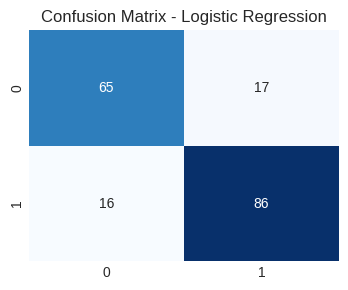

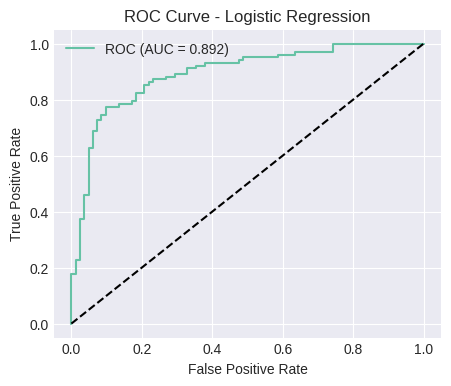


🔹 Decision Tree
   Accuracy: 0.7717
   Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.74      0.74        82
           1       0.79      0.79      0.79       102

    accuracy                           0.77       184
   macro avg       0.77      0.77      0.77       184
weighted avg       0.77      0.77      0.77       184



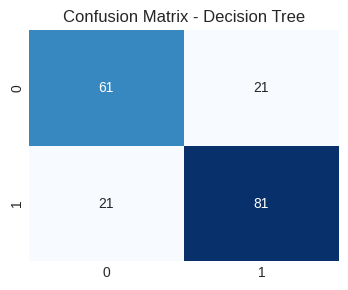

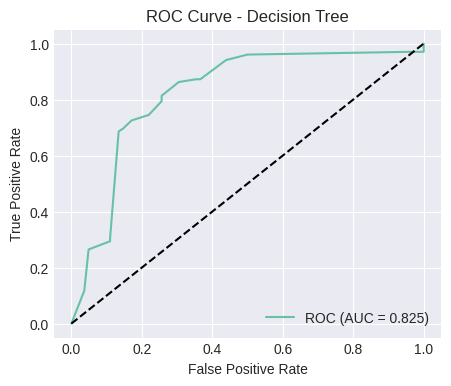

In [20]:
# Evaluation (with ROC Curve)
def evaluate_model(name, y_true, y_pred, model=None, X_test_in=None):
    acc = accuracy_score(y_true, y_pred)
    print(f"\n🔹 {name}")
    print(f"   Accuracy: {acc:.4f}")
    print("   Classification Report:")
    print(classification_report(y_true, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

    # ROC Curve (only if model supports predict_proba)
    if model and X_test_in is not None:
        proba = model.predict_proba(X_test_in)[:, 1]
        fpr, tpr, _ = roc_curve(y_true, proba)
        auc = roc_auc_score(y_true, proba)
        plt.figure(figsize=(5,4))
        plt.plot(fpr, tpr, label=f'ROC (AUC = {auc:.3f})')
        plt.plot([0,1],[0,1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - {name}')
        plt.legend()
        plt.show()

print("\n" + "="*50)
print("🎯 MODEL PERFORMANCE")
print("="*50)
evaluate_model("Logistic Regression", y_test, y_pred_lr, lr, X_test_scaled)
evaluate_model("Decision Tree", y_test, y_pred_dt, dt, X_test)

# **Feature Importance**

/tmp/ipykernel_1571/1355772937.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=imp_df, palette='viridis')


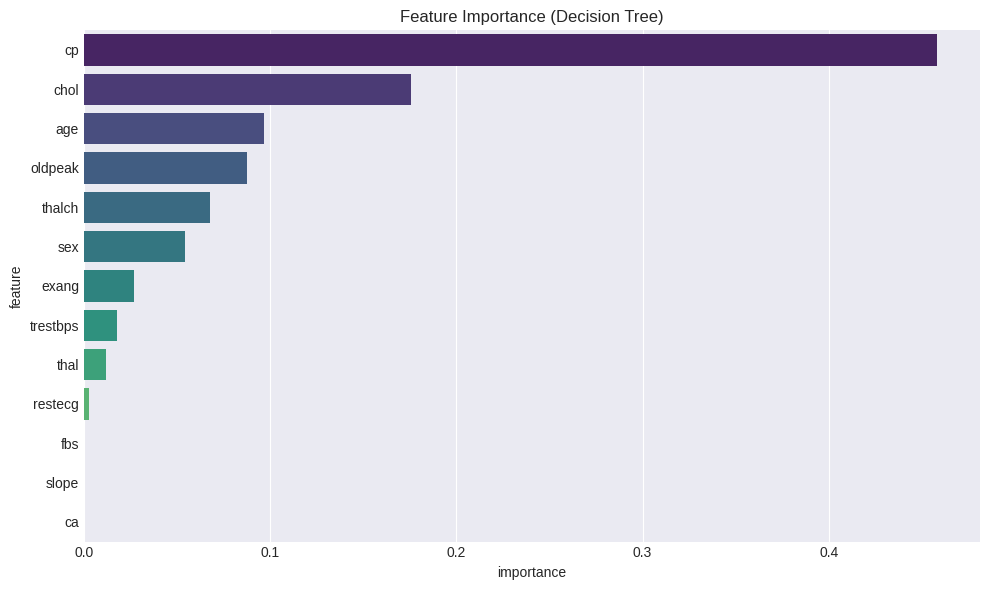


📌 Top 5 important features:
   - cp: 0.4583
   - chol: 0.1757
   - age: 0.0969
   - oldpeak: 0.0878
   - thalch: 0.0677


In [21]:
# Feature Importance (Decision Tree)
importances = dt.feature_importances_
features = X.columns
imp_df = pd.DataFrame({'feature': features, 'importance': importances}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=imp_df, palette='viridis')
plt.title('Feature Importance (Decision Tree)')
plt.tight_layout()
plt.show()

print("\n📌 Top 5 important features:")
for i, row in imp_df.head(5).iterrows():
    print(f"   - {row['feature']}: {row['importance']:.4f}")

# **Final Conclusion**

In [22]:
# Conclusion
print("\n" + "="*50)
print("✅ FINAL CONCLUSION")
print("="*50)
print(f"Logistic Regression accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Decision Tree accuracy:       {accuracy_score(y_test, y_pred_dt):.4f}")
print("\nBoth models perform well. Logistic Regression is simpler and interpretable.")
print("Most influential features:",
      ", ".join(imp_df['feature'].head(3).values))


✅ FINAL CONCLUSION
Logistic Regression accuracy: 0.8207
Decision Tree accuracy:       0.7717

Both models perform well. Logistic Regression is simpler and interpretable.
Most influential features: cp, chol, age


# **Analysis of residuals and testing the normality assumption (of model fit)**

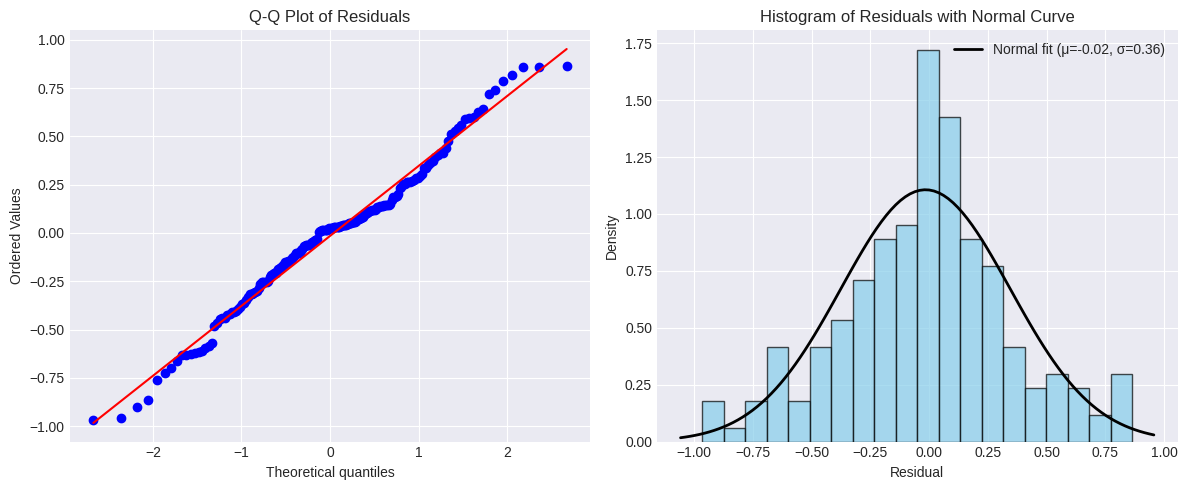


📈 NORMALITY TEST (Shapiro-Wilk)
Shapiro-Wilk statistic: 0.9843
p-value: 0.0372
⚠️ We reject the normality hypothesis (p ≤ 0.05). Residuals may not follow a normal distribution.


In [27]:
# Testing the normal distribution of residuals (Logistic Regression)
import scipy.stats as stats
import matplotlib.pyplot as plt

# Calculating predicted probabilities
y_pred_prob = lr.predict_proba(X_test_scaled)[:, 1]

# Calculating residuals = the difference between the actual value and the predicted probability
residuals = y_test - y_pred_prob

# Draw the Q-Q plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")

# Drawing a histogram with a normal distribution curve
plt.subplot(1, 2, 2)
plt.hist(residuals, bins=20, density=True, alpha=0.7, color='skyblue', edgecolor='black')
# Theoretical Normal Distribution Curve
mu, std = stats.norm.fit(residuals)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2, label=f'Normal fit (μ={mu:.2f}, σ={std:.2f})')
plt.title("Histogram of Residuals with Normal Curve")
plt.xlabel("Residual")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.show()

# Shapiro-Wilk test for the normality hypothesis
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print("\n" + "="*50)
print("📈 NORMALITY TEST (Shapiro-Wilk)")
print("="*50)
print(f"Shapiro-Wilk statistic: {shapiro_stat:.4f}")
print(f"p-value: {shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("✅ We do not reject the normal distribution hypothesis for residuals (p > 0.05).")
else:
    print("⚠️ We reject the normality hypothesis (p ≤ 0.05). Residuals may not follow a normal distribution.")